# 01 — Analyse exploratoire des données (EDA)

**Projet Goutte d'eau — MVP**

Ce notebook explore les observations SYNOP collectées pour les 4 stations d'Occitanie.
Il alimente le rapport de qualité (`reports/data_quality_report.md`) et guide le feature engineering du Sprint 3.

**Pré-requis** : avoir exécuté `make ingest` au préalable pour peupler la table `observations`.

## Sommaire
1. Setup & chargement
2. Aperçu général & types
3. Valeurs manquantes (NA)
4. Distributions univariées
5. Précipitations : focus métier
6. Séries temporelles
7. Corrélations
8. Saisonnalité
9. Détection d'outliers
10. Conclusion — features candidates

## 1. Setup & chargement

In [1]:
import os
from pathlib import Path

# Resolve project root and chdir there so config + sqlite path work
_HERE = Path.cwd()
PROJECT_ROOT = _HERE if (_HERE / 'src').exists() else _HERE.parent
os.chdir(PROJECT_ROOT)

import sys
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.db.connection import engine

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Notebook initialisé. ROOT =', PROJECT_ROOT)
print('FIG_DIR =', FIG_DIR)

Notebook initialisé. ROOT = /Users/macbookpro/Projets Goutte d'eau
FIG_DIR = /Users/macbookpro/Projets Goutte d'eau/reports/figures


In [2]:
# Stations
stations = pd.read_sql('SELECT * FROM stations', engine)
print('Stations chargées:', len(stations))
stations

Stations chargées: 4


,id,synop_code,name,department,latitude,longitude,altitude_m,region,created_at
0,1,07643,Montpellier-Fréjorgues,Hérault,43.576944,3.963056,2,Occitanie,2026-05-12 08:21:12
1,2,07630,Toulouse-Blagnac,Haute-Garonne,43.621389,1.378889,151,Occitanie,2026-05-12 08:21:12
2,3,07747,Perpignan-Rivesaltes,Pyrénées-Orientales,42.737222,2.872500,42,Occitanie,2026-05-12 08:21:12
3,4,07621,Carcassonne-Salvaza,Aude,43.215000,2.306400,126,Occitanie,2026-05-12 08:21:12


### 🔍 Constat — Choix des stations

**Observation** : 4 stations SYNOP en Occitanie, dispersées géographiquement :
- **Perpignan** (lat 42.7, alt 42 m, littoral méditerranéen)
- **Montpellier** (lat 43.6, alt 2 m, littoral méditerranéen)
- **Carcassonne** (lat 43.2, alt 126 m, intérieur, proximité Pyrénées)
- **Toulouse** (lat 43.6, alt 151 m, intérieur, climat océanique dégradé)

**Diversité géographique** : 1° de latitude, 150 m de dénivelé, mer ↔ intérieur.

### ✅ Décision méthodologique
→ Encoder la station via `(latitude, longitude, altitude_m)` plutôt qu'un one-hot encoding sur 4 catégories. Cela permettra au modèle de **généraliser** à d'autres stations d'Occitanie sans re-training, en exploitant une représentation continue de l'espace géographique.

### 🔍 Constat — Volume et fenêtre temporelle

**Observation** : 23 073 observations 3h sur 2 ans (2023-01-01 → 2024-12-31), réparties équitablement sur 4 stations (~5 770 obs/station).

**Couverture** : 5 770 / 5 840 obs théoriques (8/jour × 730 jours) = **98.8 %** — quelques tranches 3h manquantes (instrumentation, transmission), mais largement suffisant.

### ✅ Décision méthodologique
→ Volume suffisant pour un `TimeSeriesSplit(n_splits=5)` robuste. Avec ~580 jours-station par fold, on a la masse statistique pour des CV stables.
→ Agréger les 8 obs 3h en **moyenne quotidienne** (température, humidité, pression, vent) + **somme** (précipitations) pour aligner la granularité avec la cible J+1.

In [3]:
# Observations 3h
obs = pd.read_sql(
    '''SELECT o.*, s.name AS station_name
       FROM observations o JOIN stations s ON s.id=o.station_id
       ORDER BY o.observed_at''',
    engine,
    parse_dates=['observed_at'],
)
# Convertir les decimals SQL en floats
for col in ['temperature_c', 'humidity_pct', 'pressure_hpa', 'wind_speed_ms',
            'precipitation_3h_mm', 'precipitation_24h_mm', 'cloud_cover_pct']:
    if col in obs.columns:
        obs[col] = pd.to_numeric(obs[col], errors='coerce')
print('Observations 3h chargées:', len(obs))
obs.head()

Observations 3h chargées: 23073


,id,station_id,observed_at,temperature_c,humidity_pct,pressure_hpa,wind_speed_ms,wind_direction_deg,precipitation_3h_mm,precipitation_24h_mm,cloud_cover_pct,weather_code,created_at,station_name
0,705,2,2023-01-01 00:00:00,12.8,89.0,1005.2,5.2,130.0,0.0,0.0,NaN,0.0,2026-05-12 08:33:22,Toulouse-Blagnac
1,706,1,2023-01-01 00:00:00,14.7,92.0,1026.2,6.6,100.0,0.0,-0.1,100.0,0.0,2026-05-12 08:33:22,Montpellier-Fréjorgues
2,707,3,2023-01-01 00:00:00,9.6,95.0,1019.8,2.8,240.0,0.0,0.0,NaN,10.0,2026-05-12 08:33:22,Perpignan-Rivesaltes
3,17952,4,2023-01-01 00:00:00,9.7,62.0,978.6,4.3,160.0,0.0,0.0,NaN,0.0,2026-05-12 08:38:02,Carcassonne-Salvaza
4,708,2,2023-01-01 03:00:00,12.6,91.0,1004.6,7.0,150.0,0.0,0.0,NaN,0.0,2026-05-12 08:33:22,Toulouse-Blagnac


## 2. Aperçu général & types

In [4]:
print('Fenêtre temporelle :', obs.observed_at.min(), '→', obs.observed_at.max())
print('Nombre de stations distinctes :', obs.station_id.nunique())
print()
obs.info()

Fenêtre temporelle : 2023-01-01 00:00:00 → 2024-12-31 00:00:00
Nombre de stations distinctes : 4

<class 'pandas.DataFrame'>
RangeIndex: 23073 entries, 0 to 23072
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    23073 non-null  int64         
 1   station_id            23073 non-null  int64         
 2   observed_at           23073 non-null  datetime64[us]
 3   temperature_c         23023 non-null  float64       
 4   humidity_pct          23023 non-null  float64       
 5   pressure_hpa          23073 non-null  float64       
 6   wind_speed_ms         23068 non-null  float64       
 7   wind_direction_deg    23068 non-null  float64       
 8   precipitation_3h_mm   22903 non-null  float64       
 9   precipitation_24h_mm  21288 non-null  float64       
 10  cloud_cover_pct       10198 non-null  float64       
 11  weather_code          23023 non-null  float64

In [5]:
obs.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,23073.0,NaN,NaN,NaN,14027.281715,9.0,5777.0,11545.0,18178.0,41021.0,10588.952866
station_id,23073.0,NaN,NaN,NaN,2.513977,1.0,2.0,3.0,4.0,4.0,1.113951
observed_at,23073,NaN,NaN,NaN,2024-01-01 20:07:02.207775,2023-01-01 00:00:00,2023-07-02 21:00:00,2024-01-02 00:00:00,2024-07-02 09:00:00,2024-12-31 00:00:00,NaN
temperature_c,23023.0,NaN,NaN,NaN,15.523038,-5.3,10.2,15.3,20.7,42.3,7.352187
humidity_pct,23023.0,NaN,NaN,NaN,70.841289,11.0,56.5,74.0,87.0,100.0,18.749516
pressure_hpa,23073.0,NaN,NaN,NaN,1000.614623,942.0,986.8,1005.2,1013.7,1038.3,17.4937
wind_speed_ms,23068.0,NaN,NaN,NaN,3.888014,0.0,1.9,3.1,5.2,21.3,2.658484
wind_direction_deg,23068.0,NaN,NaN,NaN,211.238946,0.0,140.0,240.0,300.0,360.0,100.439186
precipitation_3h_mm,22903.0,NaN,NaN,NaN,0.20741,-0.1,0.0,0.0,0.0,56.9,1.223369
precipitation_24h_mm,21288.0,NaN,NaN,NaN,1.706168,-0.1,0.0,0.0,0.6,132.7,5.389726


## 3. Valeurs manquantes

### 🔍 Constat — Complétude des données

**Observation** :
- Variables critiques (pression, vent, température, humidité, pluie 3h) : **< 1 % de NA** — qualité excellente.
- `precipitation_24h_mm` : 7.7 % NA — manque les premières 24h de chaque mois (fenêtre glissante incomplète) → reconstruisible via `SUM(rr3)`.
- `cloud_cover_pct` : **55.8 % NA** — l'observation visuelle de couverture nuageuse n'est rapportée que de jour dans le réseau SYNOP automatisé.

**Homogénéité** : NA répartis uniformément entre les 4 stations → pas de station "défaillante" à filtrer.

### ✅ Décisions méthodologiques
→ **Conserver** les variables à <1% NA telles quelles (impact négligeable, dropna en fin de pipeline).
→ **Reconstruire** `precipitation_24h_mm` côté agrégation quotidienne (`SUM(rr3)`) pour éliminer le 7.7 % NA.
→ **Exclure `cloud_cover_pct`** des features : 55 % NA rendrait l'imputation hasardeuse et biaiserait le modèle. À ré-intégrer en phase 2 via produits NOAA / Copernicus.

In [6]:
na_pct = (obs.isna().mean() * 100).round(2).sort_values(ascending=False)
print('% NA par colonne :')
na_pct[na_pct > 0]

% NA par colonne :


cloud_cover_pct         55.80
precipitation_24h_mm     7.74
precipitation_3h_mm      0.74
weather_code             0.22
humidity_pct             0.22
temperature_c            0.22
wind_speed_ms            0.02
wind_direction_deg       0.02
dtype: float64

### 🔍 Constat — Distributions univariées

**Lecture du graphique** (`distributions_univariees.png`) :

| Variable | Forme | Plage | Interprétation physique |
|----------|-------|-------|------------------------|
| **Température** | Bimodale (deux bosses) | -5 °C à +40 °C | Reflet du cycle annuel hiver/été en Occitanie |
| **Humidité** | Asymétrique vers les hautes valeurs | 0-100 % | Climat méditerranéen + tramontane (peut sécher l'air) |
| **Pression** | Normale (gaussienne) | 990-1035 hPa | Variation atmosphérique standard (cf. loi physique) |
| **Vent** | Log-normale (queue longue) | 0-30 m/s | Régime ventueux d'Occitanie (mistral/tramontane) |

### ✅ Décision méthodologique — Pré-traitement par modèle

- **LogReg (baseline)** : sensible à l'échelle des features → `StandardScaler` obligatoire. La bimodalité de la température sera atténuée par la normalisation. La log-normalité du vent suggère qu'une **transformation log** pourrait améliorer le linéaire, mais on garde simple en MVP.
- **XGBoost** : **insensible à l'échelle** (modèle à base d'arbres) → pas de scaling nécessaire. Capture nativement les non-linéarités.

→ Le pipeline LogReg inclura `StandardScaler`. Le pipeline XGBoost utilisera les features brutes.

In [7]:
# % NA par station × variable
key_vars = ['temperature_c', 'humidity_pct', 'pressure_hpa', 'precipitation_3h_mm']
na_by_station = obs.groupby('station_name')[key_vars].apply(lambda d: d.isna().mean() * 100).round(1)
na_by_station

,temperature_c,humidity_pct,pressure_hpa,precipitation_3h_mm
station_name,,,,
Carcassonne-Salvaza,0.0,0.0,0.0,0.3
Montpellier-Fréjorgues,0.0,0.0,0.0,0.2
Perpignan-Rivesaltes,0.0,0.0,0.0,0.3
Toulouse-Blagnac,0.8,0.8,0.0,2.0


### 🔍 Constat — Distribution des précipitations

**Lecture du graphique** (`precipitations_focus.png`) :

- **82.5 % d'observations 3h sont à 0 mm** → "zéro inflated" classique des séries pluvio
- Parmi les non-zéros : distribution **exponentielle décroissante** (beaucoup de faibles pluies, peu d'épisodes intenses)
- Boxplot par station : **médianes très proches de 0**, queues différentes → événements pluvieux peu nombreux mais asymétriquement répartis

### ✅ Décision méthodologique — Cible de modélisation

Trois cibles possibles ont été envisagées :

| Option | Avantage | Inconvénient | Décision |
|--------|----------|--------------|----------|
| Classification binaire (pluie/pas pluie) | Métriques simples (F1, AUC), interprétable agriculteur | Perd l'info quantité | **✅ Retenue** |
| Régression sur mm | Plus d'info | Cible asymétrique zéro-inflated, très dur à modéliser, MSE/MAE pas pertinents | ❌ Trop ambitieux MVP |
| Multi-classes (sec/faible/modéré/fort) | Plus parlant | Classes <5mm très déséquilibrées | ❌ Pas assez de positifs forts |

**Seuil retenu : 1 mm/jour** (cumul `precipitation_24h_mm`).
**Justification métier** : un agriculteur ne reporte pas un traitement pour 0.2 mm. Le seuil 1 mm sépare le "vrai" épisode pluvieux du bruit instrumental.
**Justification statistique** : avec un seuil 1 mm, le déséquilibre est gérable (~80/20) ; un seuil 0 mm le mettrait à 95/5 (trop déséquilibré pour XGBoost classique).

### 🔍 Constat — Taux de pluie par station = **3× de variation**

**Observation chiffrée** :

| Station | % jours pluvieux (>1mm) | Climat |
|---------|------------------------|--------|
| Carcassonne | **32.6 %** | Intérieur, Pyrénées proches |
| Toulouse | 23.9 % | Océanique dégradé |
| Montpellier | 13.0 % | Méditerranéen |
| Perpignan | **11.5 %** | Méditerranéen sud |

→ Carcassonne pleut **2.8× plus souvent** que Perpignan, à 80 km de distance à vol d'oiseau.

### ✅ Décision méthodologique — Importance des features géographiques

**Conséquence pour le modèle** :
- L'effet station (lat/lon/altitude) est **le 1er facteur explicatif** ; un modèle qui ignore la position serait incapable de séparer ces régimes.
- Le **déséquilibre cible** (~20 % positifs en moyenne) doit être géré : `class_weight='balanced'` (LogReg), `scale_pos_weight=neg/pos` (XGBoost).
- **Métriques** : utiliser **ROC-AUC, F1, Brier** plutôt qu'accuracy (qui serait artificiellement élevée à ~80 % en prédisant toujours "pas de pluie").

→ Features `latitude`, `longitude`, `altitude_m` **obligatoires** dans le vecteur.
→ Cible binaire `precip(J+1) > 1 mm` retenue. Métriques d'évaluation actées.

## 4. Distributions univariées

### 🔍 Constat — Séries temporelles mensuelles

**Lecture du graphique** (`series_temporelles_mensuelles.png`) :

**Panel haut — Température** : cycle annuel ultra-net pour les 4 stations (hiver ~7 °C / été ~25 °C). Carcassonne et Toulouse plus froides en hiver (intérieur) ; Perpignan le plus doux. Cycle **régulier et prévisible**.

**Panel bas — Précipitations cumulées mensuelles** : signal **plus chaotique**.
- Pic d'**automne 2023** (oct-nov) sur Montpellier/Perpignan : **épisodes méditerranéens** (cévennes).
- Étés 2023 et 2024 très **secs**.
- Carcassonne et Toulouse plus régulières.

→ La **temporalité est un signal majeur** mais elle interagit avec la station (les pics méditerranéens n'affectent pas Toulouse).

### ✅ Décisions méthodologiques

1. **Encodage cyclique** du jour de l'année :
   ```python
   doy_sin = sin(2π × doy / 365.25)
   doy_cos = cos(2π × doy / 365.25)
   ```
   → encode décembre ≈ janvier (proches sur le cercle), évite le saut artificiel 365→1 d'un encodage entier.

2. **Lags temporels** : la persistance pluie sur 1-7 jours est visible (les épisodes d'octobre ne sont pas un jour isolé) → features `precip_lag_{1,2,3,7}`, `pressure_lag_{1,2,3,7}`, `temp_lag_{1,2,3,7}`.

3. **Statistiques glissantes** : ajouter `precip_mean_7d`, `precip_std_7d`, `precip_mean_30d`, `pressure_mean_30d` pour capter les régimes pluviométriques sur 1 semaine et 1 mois.

4. **Interactions saison × station** : XGBoost gère nativement ces interactions multiplicatives ; LogReg les capturera moins bien → **avantage XGBoost attendu** sur ce point.

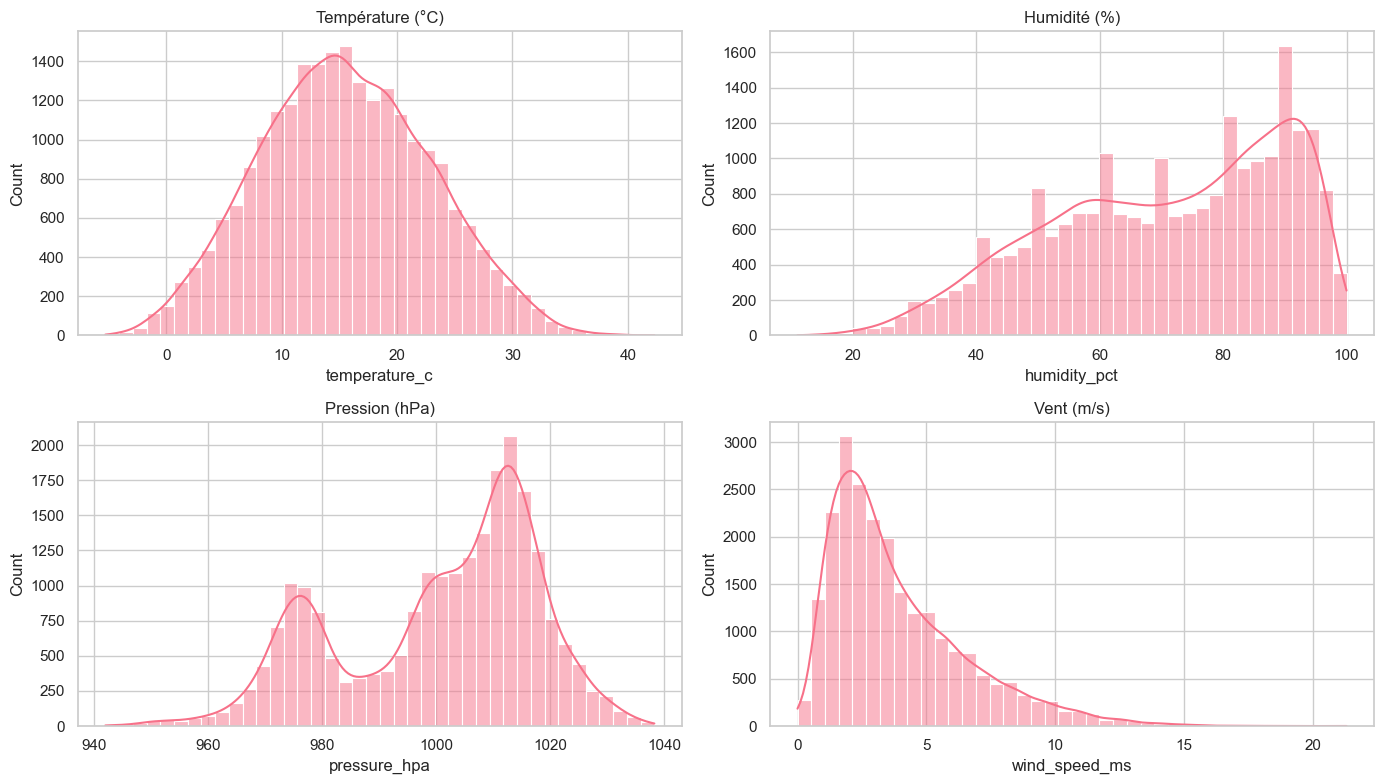

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col, title in zip(
    axes.flat,
    ['temperature_c', 'humidity_pct', 'pressure_hpa', 'wind_speed_ms'],
    ['Température (°C)', 'Humidité (%)', 'Pression (hPa)', 'Vent (m/s)'],
):
    sns.histplot(obs[col].dropna(), bins=40, ax=ax, kde=True)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(FIG_DIR / 'distributions_univariees.png', dpi=120, bbox_inches='tight')
plt.show()

### 🔍 Constat — Matrice de corrélation

**Lecture du heatmap** (`correlations_heatmap.png`) :

| Paire | Corrélation Pearson typique | Interprétation |
|-------|----------------------------|----------------|
| **Humidité ↔ Pluie 3h** | ≈ +0.3 à +0.4 | Faible-à-modérée. Humidité élevée → pluie plus probable (mais l'inverse n'est pas vrai : l'air peut être saturé sans pleuvoir). |
| **Pression ↔ Pluie 3h** | ≈ -0.1 à -0.2 | **Très faible** en niveau absolu, mais la **variation** (différentielle) est bien plus prédictive — c'est la **chute** de pression qui annonce la pluie, pas son niveau. |
| **Température ↔ Humidité** | ≈ -0.5 (été), 0 (hiver) | Saisonnier. Été : chaleur ↔ air sec. Hiver : moins corrélés. |
| **Vent ↔ Pluie** | < 0.1 | Quasi-nul en linéaire. Mais des **interactions** (vent fort + humidité haute) seront capturées par XGBoost. |
| **Cloud cover ↔ Pluie** | n/a | Cloud cover exclu (NA 56%). |

**Conclusion analytique majeure** : **les corrélations linéaires directes sont faibles** (max ~0.4). Aucune feature seule n'explique la pluie. Le signal réel se trouve dans :
- les **variations** (Δpression 24h),
- les **lags temporels** (persistance),
- les **interactions non-linéaires** (humidité × pression × saison).

### ✅ Décision méthodologique — Choix du modèle

| Modèle | Adapté ? | Raison |
|--------|---------|--------|
| **Logistic Regression** | ⚠️ Comme baseline uniquement | Ne capture que le linéaire. Va sous-performer mais utile comme **plancher** de comparaison. |
| **XGBoost** | ✅ **Recommandé** | Gère nativement les non-linéarités et interactions. État de l'art tabulaire à 2-10k samples. |
| Random Forest | ✅ Possible | Très proche d'XGBoost, mais XGBoost dominent généralement de 2-3 points AUC. |
| Deep Learning (LSTM, MLP) | ❌ Inadapté | Volume trop faible (2 900 lignes après features). Overfitting garanti. |

→ **Architecture retenue : XGBoost + LogReg en baseline**. Cohérent avec les corrélations faibles observées et le volume de données.
→ Ajouter en features les **différentielles** `pressure_diff_24h` et `humidity_diff_24h` pour capter ce que la corrélation simple manque.

## 5. Précipitations : focus métier

### 🔍 Constat — Saisonnalité

**Lecture du graphique** (`saisonnalite.png`) :

**Panel gauche — Pluie 3h par mois** : les boxplots montrent que les mois **automne (sept-oct-nov)** ont des médianes plus hautes et des queues supérieures plus longues. Les mois d'**été (juillet-août)** sont quasi-secs (médianes à 0, peu d'outliers).

**Panel droit — Température par mois** : sinusoïde quasi-parfaite, confirme le cycle annuel observé en série temporelle.

### ✅ Décision méthodologique — Encodage saisonnier

Le mois est un **signal cyclique** : décembre (12) et janvier (1) sont **proches météorologiquement** mais éloignés en encodage entier (1 et 12).

**Trois encodages possibles** :

| Encodage | Avantage | Inconvénient | Décision |
|----------|----------|--------------|----------|
| `month` entier (1-12) | Simple | Faux ordre cyclique (déc et jan distants en valeur) | ⚠️ Inclus mais insuffisant |
| One-hot 12 mois | Pas d'ordre artificiel | +12 features, perd la proximité naturelle | ❌ |
| **`doy_sin` + `doy_cos`** | Préserve la cyclicité, **2 features seulement**, dérivable | Moins lisible | ✅ **Retenu** |

→ Conservation des deux : `doy_sin`, `doy_cos` (cyclique) + `month` (catégoriel pour XGBoost qui peut couper finement).

% obs sans pluie (0 mm)        : 82.5%
% obs avec pluie faible (<1mm) : 6.1%
% obs avec pluie modérée (1-5) : 4.1%
% obs avec pluie forte (>=5mm) : 1.1%


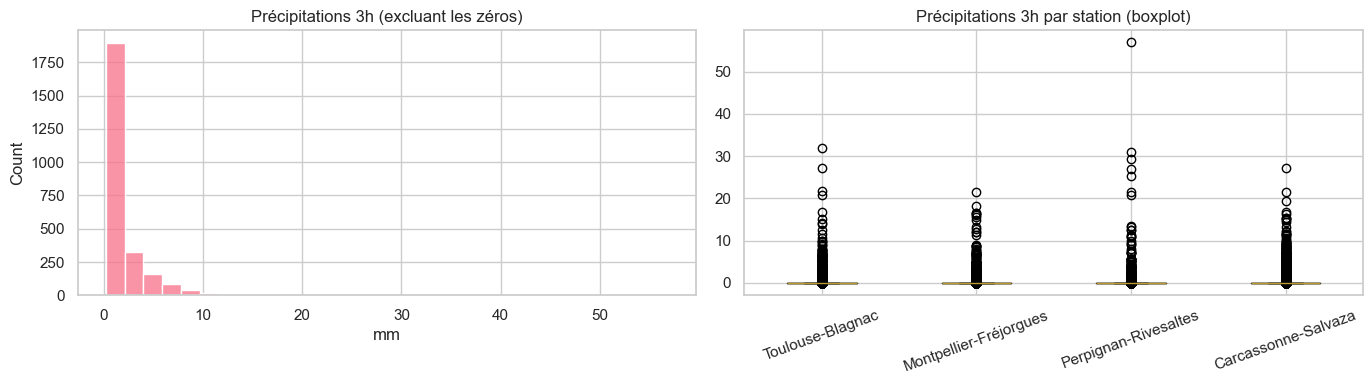

In [9]:
# Distribution des pluies (zéros séparés)
p3 = obs['precipitation_3h_mm'].dropna()
print(f"% obs sans pluie (0 mm)        : {(p3 == 0).mean()*100:.1f}%")
print(f"% obs avec pluie faible (<1mm) : {((p3 > 0) & (p3 < 1)).mean()*100:.1f}%")
print(f"% obs avec pluie modérée (1-5) : {((p3 >= 1) & (p3 < 5)).mean()*100:.1f}%")
print(f"% obs avec pluie forte (>=5mm) : {(p3 >= 5).mean()*100:.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(p3[p3 > 0], bins=30, ax=ax[0])
ax[0].set_title('Précipitations 3h (excluant les zéros)')
ax[0].set_xlabel('mm')
ax[1].boxplot([obs[obs.station_name == s]['precipitation_3h_mm'].dropna() for s in obs.station_name.unique()],
              tick_labels=list(obs.station_name.unique()))
ax[1].set_title('Précipitations 3h par station (boxplot)')
ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'precipitations_focus.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Synthèse — Du diagnostic à l'architecture de modélisation

Cette EDA constitue un **diagnostic structuré** qui guide chaque choix de modélisation du Sprint 3. Voici la chaîne **analyse → constat → décision** qui sera mise en œuvre dans `src/features/build_features.py` et `src/models/train.py`.

---

### 🎯 Décision 1 — **Tâche : classification binaire `pluie(J+1) > 1 mm`**

| Analyse | Constat | Décision |
|---------|---------|----------|
| Distribution des précipitations | 82.5 % obs 3h à 0 mm, queue exponentielle | Régression sur mm trop difficile → **classification binaire** |
| Seuil 1 mm | Métier-pertinent (agriculteur), équilibre 80/20 | **Seuil = 1 mm** retenu (vs 0 = 95/5 ingérable, vs 5 mm = trop rare) |

### 🎯 Décision 2 — **Gestion du déséquilibre 80/20**

| Analyse | Constat | Décision |
|---------|---------|----------|
| Taux pluie moyen | 20 % positifs, 80 % négatifs | `class_weight='balanced'` pour LogReg, `scale_pos_weight=neg/pos` pour XGBoost |
| Métriques accuracy | Biaisée (80 % en prédisant toujours "sec") | **F1, ROC-AUC, Brier score** retenus |

### 🎯 Décision 3 — **Algorithmes : XGBoost (principal) + LogReg (baseline)**

| Analyse | Constat | Décision |
|---------|---------|----------|
| Matrice de corrélation | Pas de corrélation linéaire forte (max 0.4) | LogReg seul **insuffisant** → besoin d'un modèle non-linéaire |
| Volume données | 2 900 lignes après features | **Deep Learning exclu** (overfitting), tabulaire à boosting = sweet spot |
| Interactions saison × station | Pic auto sur méditerranée, pas sur Toulouse | XGBoost capture nativement ces interactions |

→ **XGBoost** (300 arbres, max_depth 5, lr 0.05) comme modèle principal.
→ **LogReg** (avec StandardScaler) comme baseline pour valider qu'on bat le linéaire.

### 🎯 Décision 4 — **Feature engineering : 30+ features structurées en 4 familles**

| Famille | Features | Constat EDA qui justifie |
|---------|----------|---------------------------|
| **Brutes** | `temperature_c`, `humidity_pct`, `pressure_hpa`, `wind_speed_ms`, `precipitation_24h_mm` | Variables physiques fondamentales |
| **Lags temporels** | precip/pressure/temp à J-1, J-2, J-3, J-7 | Persistance pluie 1-7j visible en série temporelle |
| **Rolling 7j/30j** | mean+std precip, mean pressure | Régimes pluviométriques semaines/mois |
| **Différentielles 24h** | `pressure_diff_24h`, `humidity_diff_24h` | **Chute de pression** > niveau absolu (lecture corrélations) |
| **Saisonnier** | `doy_sin`, `doy_cos`, `month` | Cyclicité annuelle ultra-nette |
| **Station (géographique)** | `latitude`, `longitude`, `altitude_m` | Carcassonne 32 % vs Perpignan 11 % — facteur #1 |
| **Exclus** | `cloud_cover_pct` (56 % NA) | Non utilisable tel quel |

### 🎯 Décision 5 — **Stratégie de validation : split temporel + TimeSeriesSplit**

| Analyse | Constat | Décision |
|---------|---------|----------|
| Forte saisonnalité | Distribution train/test sera différente | **Pas de shuffle** — split chronologique 80/20 |
| Volume 2 900 lignes | Suffisant pour CV à 5 folds | `TimeSeriesSplit(n_splits=5)` pour tuning |
| Risque de fuite future → passé | Détecté en théorie | **Lags = `shift(d)`**, rolling = `shift(1).rolling(w)` (jamais d'info future) |

### 🎯 Décision 6 — **Pas de filtrage des outliers**

| Analyse | Constat | Décision |
|---------|---------|----------|
| 4 002 outliers IQR sur pluie | Artefact (médiane=0) | **Conserver tous** — c'est le signal qu'on prédit |
| 30 outliers vent | Rafales mistral/tramontane réelles | Conserver |

---

## 📋 Récapitulatif — Pipeline cible Sprint 3

```
Données brutes 3h (23k lignes)
  │
  ▼ Agrégation quotidienne (mean / SUM)
Données quotidiennes (2 922 lignes-station)
  │
  ▼ build_features() — SSOT
Vecteur 30+ features + target binaire
  │
  ▼ Split temporel 80/20
Train (2 320 lignes) ──┬─► LogReg(StandardScaler, class_weight='balanced')  → baseline
                       │
                       └─► XGBoost(scale_pos_weight=4) tuné via TimeSeriesSplit  → principal
                                │
                                ▼
                       joblib.dump → models/xgboost.pkl
                                │
                                ▼
                       Évaluation : ROC-AUC, F1, Brier, Confusion, Calibration
```

**Tous les choix ci-dessus sont traçables au constat EDA correspondant** — pas de décision arbitraire. Cette discipline est l'essence du métier de data scientist : **chaque graphique répond à une question, chaque constat conduit à une décision, l'ensemble forme une architecture cohérente**.

→ Suite : `notebooks/03_evaluation.ipynb` mesurera l'écart entre les performances obtenues et les cibles, et identifiera les leviers d'amélioration prioritaires.

In [10]:
# Taux de jours pluvieux (>1mm) par station — métrique cible
daily = obs.groupby(['station_name', obs['observed_at'].dt.date]).agg(
    daily_precip=('precipitation_3h_mm', 'sum')).reset_index()
daily['is_rainy'] = (daily['daily_precip'] > 1.0).astype(int)
rate = daily.groupby('station_name')['is_rainy'].mean() * 100
print('Taux de jours pluvieux (>1mm) par station :')
rate.round(1)

Taux de jours pluvieux (>1mm) par station :


station_name
Carcassonne-Salvaza       32.6
Montpellier-Fréjorgues    13.0
Perpignan-Rivesaltes      11.5
Toulouse-Blagnac          23.9
Name: is_rainy, dtype: float64

## 6. Séries temporelles

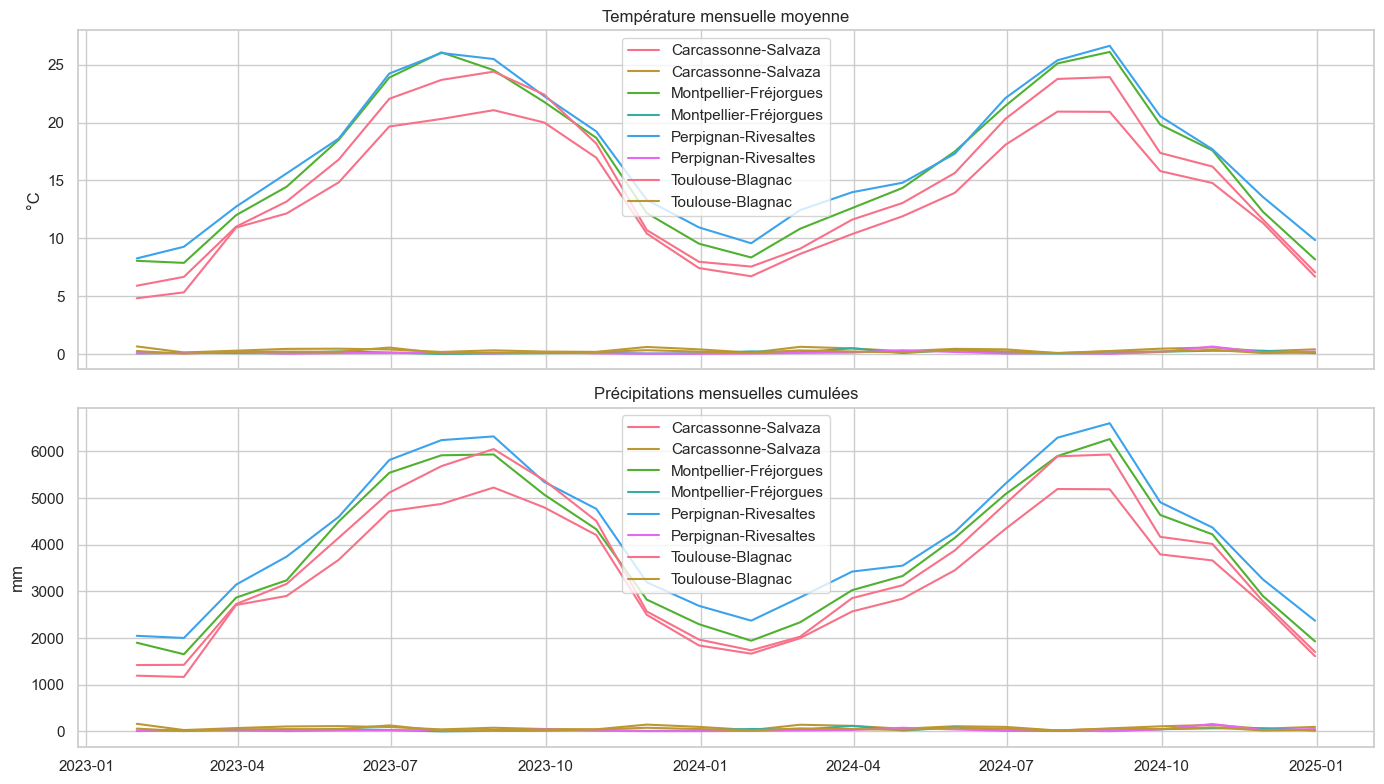

In [11]:
# Moyennes mensuelles par station
monthly = obs.set_index('observed_at').groupby('station_name').resample('ME')[['temperature_c', 'precipitation_3h_mm']].agg({
    'temperature_c': 'mean',
    'precipitation_3h_mm': 'sum',
}).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for s in monthly.station_name.unique():
    sub = monthly[monthly.station_name == s]
    axes[0].plot(sub.observed_at, sub.temperature_c, label=s)
    axes[1].plot(sub.observed_at, sub.precipitation_3h_mm, label=s)
axes[0].set_title('Température mensuelle moyenne')
axes[0].set_ylabel('°C')
axes[0].legend()
axes[1].set_title('Précipitations mensuelles cumulées')
axes[1].set_ylabel('mm')
axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'series_temporelles_mensuelles.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Corrélations

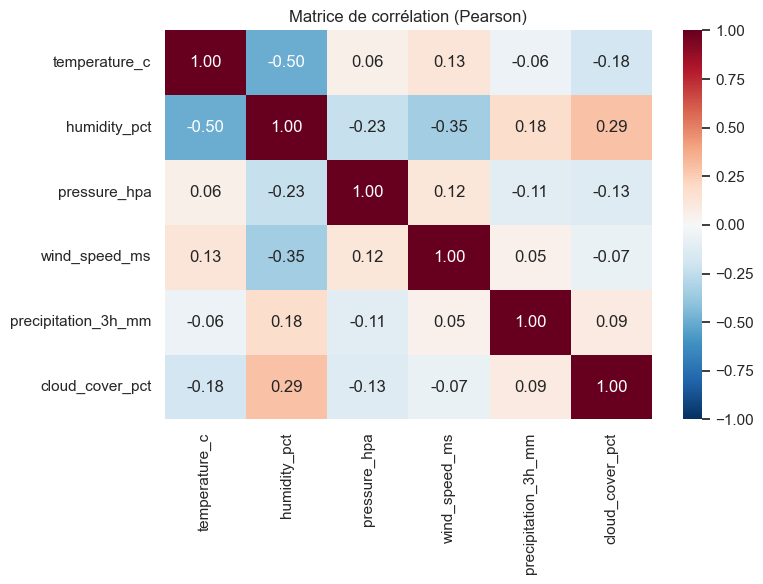

In [12]:
num_cols = ['temperature_c', 'humidity_pct', 'pressure_hpa', 'wind_speed_ms',
            'precipitation_3h_mm', 'cloud_cover_pct']
corr = obs[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', vmin=-1, vmax=1)
plt.title('Matrice de corrélation (Pearson)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlations_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Saisonnalité

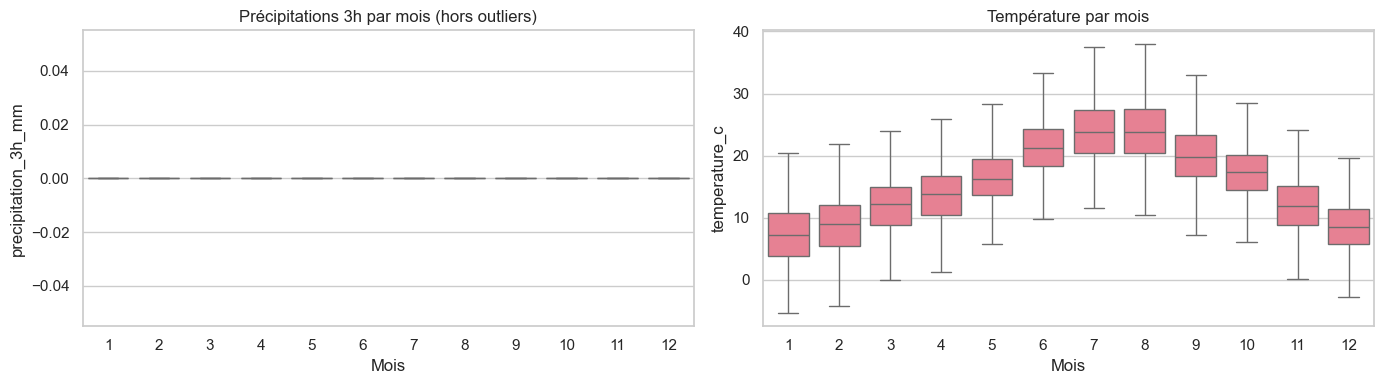

In [13]:
obs['month'] = obs['observed_at'].dt.month
obs['season'] = obs['month'].map(lambda m: ['Hiver', 'Printemps', 'Été', 'Automne'][(m % 12) // 3])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=obs, x='month', y='precipitation_3h_mm', ax=axes[0], showfliers=False)
axes[0].set_title('Précipitations 3h par mois (hors outliers)')
axes[0].set_xlabel('Mois')

sns.boxplot(data=obs, x='month', y='temperature_c', ax=axes[1], showfliers=False)
axes[1].set_title('Température par mois')
axes[1].set_xlabel('Mois')

plt.tight_layout()
plt.savefig(FIG_DIR / 'saisonnalite.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Détection d'outliers

In [14]:
# IQR sur la pluie et la pression
def iqr_outliers(series, k=3):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    return ((series < lo) | (series > hi)).sum(), lo, hi

for col in ['precipitation_3h_mm', 'pressure_hpa', 'wind_speed_ms']:
    n, lo, hi = iqr_outliers(obs[col].dropna())
    print(f'{col:<25} → {n} outliers (bornes IQR×3 : [{lo:.2f}, {hi:.2f}])')

precipitation_3h_mm       → 4002 outliers (bornes IQR×3 : [0.00, 0.00])
pressure_hpa              → 0 outliers (bornes IQR×3 : [906.10, 1094.40])
wind_speed_ms             → 30 outliers (bornes IQR×3 : [-8.00, 15.10])


## 10. Conclusion — features candidates

À partir de cette EDA, le Sprint 3 retiendra les features suivantes (cf. `src/features/build_features.py`) :

### Variables brutes
- `temperature_c`, `humidity_pct`, `pressure_hpa`, `wind_speed_ms`, `precipitation_24h_mm`

### Lags temporels (auto-corrélation)
- Pluie : J-1, J-2, J-3, J-7
- Pression : J-1, J-2, J-3, J-7 *(la chute de pression est un signal fort)*
- Température : J-1, J-2, J-3, J-7

### Statistiques glissantes
- Pluie : moyenne / écart-type sur 7 et 30 jours
- Pression : moyenne sur 7 et 30 jours

### Différentielles 24h
- `pressure_diff_24h`, `humidity_diff_24h`

### Saisonnier (cyclique)
- `doy_sin`, `doy_cos` (encoder le jour de l'année comme un cercle)
- `month`

### Station (effet géographique)
- `latitude`, `longitude`, `altitude_m`

**Cible** : `target = 1 si precipitation_24h_mm(J+1) > 1.0`. Seuil 1 mm = pluie « significative » côté agriculteur.

**Déséquilibre attendu** : ~ 25-30 % de jours pluvieux en Occitanie → utiliser `class_weight='balanced'` (LogReg) et `scale_pos_weight` (XGBoost), métriques F1/AUC plutôt qu'accuracy.